### LAB 2: Generation of Random number using pseudo Random and Chi-Square test.

#### Objective:
To use pseudo random and chi-square test for random number generation.

#### Theory:

A random number is an element of a sequence of numbers chosen entirely by chance from a specified distribution. In computational systems, true randomness is difficult to achieve deterministically, leading to the use of pseudorandom numbers sequences that appear random but are generated by a predictable mathematical formula.

Characteristics and Conditions of Ideal Random Numbers:

For a sequence to be considered effectively random, it must satisfy two core statistical conditions:
1. Uniformity: The generated numbers must be uniformly distributed over a given interval (typically [0, 1) or a defined range of integers). This means every possible number in the set has an equal probability of being chosen.
2. Independence (Unpredictability): It must be mathematically impossible to predict or detect future values in the sequence based on past or present values. There should be no discernible correlation between successive numbers.

*Random Variable*:
random variable is a variable whose possible values are numerical outcomes of a random phenomenon. Random number generation forms the backbone of several modern technical fields:

*Application*:

Cybersecurity: Used for generating cryptographic keys, salts, and nonces to secure data encryption.

Machine Learning: Essential for shuffling datasets, initializing weights in neural networks, and setting up stochastic gradient descent.

Scientific Studies & Simulations: Powers Monte Carlo simulations to model complex physical, economic, or biological systems where uncertainty is a factor.

*Algorithm for generating random number*

Pseudorandom Number Generators (PRNGs) use mathematical formulas to create long sequences of numbers starting from an initial value called a seed (X_0).
While algorithms like the Mersenne Twister (highly complex, long period) and XORshift (extremely fast, hardware-friendly) are widely used in modern software, the foundational method is the Linear Congruential Generator.
##### Linear Congruential Generator (LCG)

The LCG is one of the oldest, best-understood, and most common pseudorandom number generator algorithms. It is highly favored because it is incredibly fast and requires minimal computational memory.

The sequence of integers $X_n$ is established by the recurrence relation:

$$X_{n+1} = (aX_n + c) \pmod m$$

Where the parameters are defined as:
* $X_0$: The **initial seed** or start value ($X_0 \geq 0$).
* $m$: The **modulus** ($0 < m$). It defines the maximum range of the sequence and its maximum possible period.
* $a$: The **multiplier** ($0 < a < m$).
* $c$: The **increment** ($0 \leq c < m$).

When $c = 0$, the generator is often called a *Multiplicative Congruential Generator*. The choice of these constants heavily impacts the "randomness" and the period length before the sequence begins repeating itself.

*statistical testing*: Why the Chi-Square Test?
Because PRNGs rely on deterministic mathematical formulas, they can sometimes introduce hidden patterns, biases, or periodicities. Therefore, statistical validation is required. 

The **Chi-Square ($\chi^2$) Goodness-of-Fit Test** is employed to evaluate whether an empirically generated sequence of numbers behaves like a truly uniform random distribution or not. It tests the null hypothesis ($H_0$) that the observed frequencies of numbers match the theoretically expected uniform distribution.

##### Mathematical Formula
To perform the test, the range of random numbers is divided into $n$ sub-intervals or "bins". The Chi-Square statistic is calculated using the formula:

$$\chi^2 = \sum_{i=1}^{n} \frac{(O_i - E_i)^2}{E_i}$$

Where:
* $O_i$: The **Observed frequency** (the actual count of random numbers that fell into bin $i$ during your code execution).
* $E_i$: The **Expected frequency** for bin $i$ assuming a perfectly uniform distribution. For a total sample size of $N$ numbers distributed evenly across $n$ bins, $E_i = \frac{N}{n}$.
* $n$: The total **number of bins** (sub-intervals).

##### Decision Rule
The calculated $\chi^2$ value is compared against a critical value from a Chi-Square distribution table based on a chosen significance level (e.g., $\alpha = 0.05$) and the degrees of freedom ($df = n - 1$). 
* If $\chi^2 \le \text{Critical Value}$, we fail to reject the null hypothesis, meaning the generated numbers are statistically uniform (the test passes).
* If $\chi^2 > \text{Critical Value}$, we reject the null hypothesis, meaning the sequence lacks uniformity and fails the randomness criteria.


### Code Implementation

1. Constand Initialization

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Constants
iterator = 256        # Number of random numbers to generate
a = 29                # Multiplier (a)
b = 37                # Increment (c)
p = 256               # Modulus (m)
n = 8                 # Number of bins for the Chi-Square test
x02 = 0               # Variable to accumulate the calculated Chi-Square statistic
seed = 17             # Initial seed value

2. Array configuration and seeding

Before computing, empty memory arrays are prepared to track data, and the initial seed is placed.

The seed is the initial random state X₀. Here it's set manually with r[0] = 17. Since every later term is a deterministic function of this starting value (via the recurrence in Section 3), re-running the notebook always reproduces the exact same sequence, we can change this one number to get a different but equally reproducible sequence.

In [51]:
r = np.ones(shape=(iterator), dtype=int)   # Storage array for the generated sequence
ei = iterator / n                          # Expected frequency per bin (256 numbers / 8 bins = 32 per bin)
c = np.zeros(shape=(n), dtype=int)         # Counter array initialized to zeros to store bin frequencies
r[0] = seed                                # Setting the initial seed (X_0 = 17)

3. Random Number generation

In [52]:
for i in range(0, iterator - 1):
    r[i + 1] = (r[i] * a + b) % p

4. Frequency Binning

In [53]:
for i in range(iterator):
    if r[i] <= 31:    c[0] += 1
    elif r[i] <= 63:  c[1] += 1
    elif r[i] <= 95:  c[2] += 1
    elif r[i] <= 127: c[3] += 1
    elif r[i] <= 159: c[4] += 1
    elif r[i] <= 191: c[5] += 1
    elif r[i] <= 223: c[6] += 1
    elif r[i] <= 255: c[7] += 1

5. statistical assesment

In [54]:
for i in range(n):
    x02 += ((c[i] - ei) ** 2) / ei

Printing the results

In [55]:
print("Values of r:", r)
print("Values of c (bin frequencies):", c)
print("Value of Chi-Square statistic (x02):", x02)
print("The critical value is", critical_value)
print("Chi square test passed" if x02 <= critical_value else "Chi square test failed")

Values of r: [ 17  18  47 120 189 142  59 212  41 202   7 240  85 198 147 204  65 130
 223 104 237 254 235 196  89  58 183 224 133  54  67 188 113 242 143  88
  29 110 155 180 137 170 103 208 181 166 243 172 161  98  63  72  77 222
  75 164 185  26  23 192 229  22 163 156 209 210 239  56 125  78 251 148
 233 138 199 176  21 134  83 140   1  66 159  40 173 190 171 132  25 250
 119 160  69 246   3 124  49 178  79  24 221  46  91 116  73 106  39 144
 117 102 179 108  97  34 255   8  13 158  11 100 121 218 215 128 165 214
  99  92 145 146 175 248  61  14 187  84 169  74 135 112 213  70  19  76
 193   2  95 232 109 126 107  68 217 186  55  96   5 182 195  60 241 114
  15 216 157 238  27  52   9  42 231  80  53  38 115  44  33 226 191 200
 205  94 203  36  57 154 151  64 101 150  35  28  81  82 111 184 253 206
 123  20 105  10  71  48 149   6 211  12 129 194  31 168  45  62  43   4
 153 122 247  32 197 118 131 252 177  50 207 152  93 174 219 244 201 234
 167  16 245 230  51 236 225 162 127 1

6. Visualization

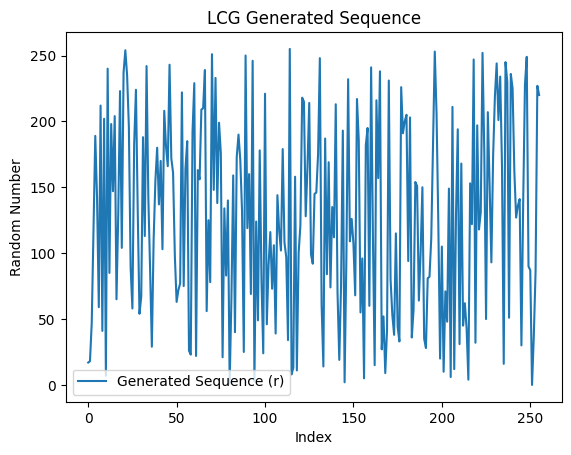

In [56]:
plt.figure()
plt.plot(r, label="Generated Sequence (r)")
plt.xlabel("Index")
plt.ylabel("Random Number")
plt.title("LCG Generated Sequence")
plt.legend()
plt.show()

Methodology and code for how seed is done

Methodology

### 5. Discussion
In this lab, we used random number generation tools to generate random number. we implementated Linear Congruential Generator (LCG) to demonstrates how a purely deterministic mathematical formula can effectively simulate a uniform sequence of pseudorandom numbers. By utilizing parameters such as the multiplier , increment, modulus), and an initial seed, the algorithm mapped values systematically across a predefined integer range. The uniformity of this generated sequence was rigorously evaluated using the Chi-Square Goodness-of-Fit test. By categorizing the outcomes into predefined sub-intervals (bins), we directly compared the observed frequencies against the theoretically expected uniform distribution. The calculated $\chi^2$ statistic served as a mathematical measure of divergence; because this value remained below the critical threshold defined by the degrees of freedom and our significance level, the null hypothesis could not be rejected. This statistical validation confirms that the LCG managed to spread the numbers evenly without introducing severe clustered biases or immediate periodic repetitions within the test sample.



### 6. Conclusion
In this laboratory experiment, we successfully generated pseudo-random numbers using the Linear Congruential Generator algorithm and validated their statistical behavior via the Chi-Square test. The experiment highlights the dual nature of computational randomness: while the sequence is entirely reproducible when initialized with a fixed seed, it still satisfies the core requirement of spatial uniformity across an interval. The Chi-Square test proved to be a reliable metric for verifying this uniformity, providing a clear mathematical boundary to accept or reject the quality of the generator. Ultimately, we concluded that the choice of LCG constants and seed initialization is fundamental to the algorithm's performance, and the resulting sequence successfully passed the statistical criteria required to be deemed effectively pseudo-random for simulated applications.